# Carregar dados e importar bibliotécas

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans
from collections import Counter


pd.reset_option('all')

dados1 = pd.read_pickle('brute_data/jogosInfo.pkl')

dados_copia = dados1.copy()

C:\Users\sousa\AppData\Local\Temp\ipykernel_16448\26554630.py:11: FutureWarning: data_manager option is deprecated and will be removed in a future version. Only the BlockManager will be available.
  pd.reset_option('all')
C:\Users\sousa\AppData\Local\Temp\ipykernel_16448\26554630.py:11: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.reset_option('all')


# Criar novas colunas extraindo informações da coluna 'data'

In [ ]:


def pegarTipo(linha):
   try:
      data = linha["dados"]
      return data["type"]
   except:
      return None

# Aplica a função pegarTipo a cada linha do DataFrame dados_copia e armazena o resultado na nova coluna 'tipo'
dados_copia["tipo"] = dados_copia.apply(pegarTipo, axis=1)


def jogoGratuito(linha):
    try:
        dados = linha["dados"]
        return dados["is_free"]
    except:
        return None

# Aplica a função jogoGratuito a cada linha do DataFrame dados_copia e armazena o resultado na nova coluna 'gratuito'
dados_copia["gratuito"] = dados_copia.apply(jogoGratuito, axis=1)

def pegarIdade(linha):
    try:
        dados = linha["dados"]
        return dados["required_age"]
    except:
        return None

# Aplica a função pegarIdade a cada linha do DataFrame dados_copia e armazena o resultado na nova coluna 'idade'
dados_copia["idade"] = dados_copia.apply(pegarIdade, axis=1)

def pegarGeneros(linha):
    try:
        dados = linha["dados"]
        aux = dados["genres"]
        return [elemento["description"] for elemento in aux]
    except:
        return None
# Aplica a função pegarGeneros a cada linha do DataFrame dados_copia e armazena o resultado na nova coluna 'generos'
dados_copia["generos"] = dados_copia.apply(pegarGeneros, axis=1)

def pegarCategorias(linha):
    try:
        dados = linha["dados"]
        aux = dados["categories"]
        return [elemento["description"] for elemento in aux]
    except:
        return None

# Aplica a função pegarCategorias a cada linha do DataFrame dados_copia e armazena o resultado na nova coluna 'categorias'
dados_copia["categorias"] = dados_copia.apply(pegarCategorias, axis=1)

def pegarData(linha):
    try:
        dados = linha["dados"]
        return dados["release_date"]["date"]
    except:
        return None

# Aplica a função pegarData a cada linha do DataFrame dados_copia e armazena o resultado na nova coluna 'lancamento'
dados_copia["lancamento"] = dados_copia.apply(pegarData, axis=1)

dados_copia.drop("dados", axis=1, inplace=True)

dados_copia

,num,nome,currentPlayers,peak24h,allTimePeak,gameID,tags,analises recentes texto,analises recentes qtd,analises recentes positivas,analises totais texto,analises totais qtd,analises totais positivas,tipo,gratuito,idade,generos,categorias,lancamento
0,1,Counter-Strike 2,1274295,1527573,1818773,730,"[FPS, Shooter, Multiplayer, Competitive, Actio...","82% of the 67,962 user reviews in the last 30 ...",67962,82,"87% of the 8,133,285 user reviews for this gam...",8133285,87,game,True,0,"[Action, Free to Play]","[Multi-player, Cross-Platform Multiplayer, Ste...","Aug 21, 2012"
1,2,Dota 2,697691,716906,1295114,570,"[Free to Play, MOBA, Multiplayer, Strategy, eS...","72% of the 21,314 user reviews in the last 30 ...",21314,72,"81% of the 2,268,984 user reviews for this gam...",2268984,81,game,True,0,"[Action, Strategy, Free to Play]","[Multi-player, Co-op, Steam Trading Cards, Ste...","Jul 9, 2013"
2,3,PUBG: BATTLEGROUNDS,450881,631467,3257248,578080,"[Survival, Shooter, Battle Royale, Multiplayer...","66% of the 22,235 user reviews in the last 30 ...",22235,66,"58% of the 2,387,631 user reviews for this gam...",2387631,58,game,True,0,"[Action, Adventure, Massively Multiplayer, Fre...","[Multi-player, PvP, Online PvP, Stats, Remote ...","Dec 21, 2017"
3,4,Apex Legends,245878,357225,624473,1172470,"[Free to Play, Battle Royale, Multiplayer, FPS...","52% of the 10,986 user reviews in the last 30 ...",10986,52,"77% of the 841,111 user reviews for this game ...",841111,77,game,True,0,"[Action, Adventure, Free to Play]","[Multi-player, PvP, Online PvP, Co-op, Online ...","Nov 4, 2020"
4,5,Source SDK Base 2007,168144,187294,221857,218,None,None,None,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,Devil Slayer - Raksasi / 斩妖Raksasi,20,26,1080,1016600,"[Difficult, Action Roguelike, Top-Down, Action...",None,None,None,"84% of the 2,647 user reviews for this game ar...",2647,84,game,False,0,"[Action, Adventure, Indie]","[Single-player, Steam Achievements, Full contr...","Apr 22, 2021"
4996,4997,DEEEER Simulator: Your Average Everyday Deer Game,20,25,251,1018800,"[Exploration, Sandbox, Physics, Funny, Third P...",97% of the 38 user reviews in the last 30 days...,38,97,"92% of the 3,307 user reviews for this game ar...",3307,92,game,False,0,"[Action, Casual, Indie, Simulation]","[Single-player, Steam Achievements, Partial Co...","Nov 23, 2021"
4997,4998,Wanba Warriors,20,31,720,1021770,"[Fighting, Multiplayer, Funny, Parody , PvP, L...",87% of the 16 user reviews in the last 30 days...,16,87,"91% of the 2,195 user reviews for this game ar...",2195,91,game,False,0,"[Action, Indie]","[Single-player, Multi-player, PvP, Online PvP,...","Mar 25, 2020"
4998,4999,Coloring Game,20,31,593,1026820,"[Free to Play, Relaxing, Pixel Graphics, Casua...",96% of the 25 user reviews in the last 30 days...,25,96,"92% of the 3,855 user reviews for this game ar...",3855,92,game,True,0,"[Casual, Free to Play, Indie]","[Single-player, Steam Achievements, Steam Cloud]","Apr 12, 2019"


# Calculo do numero e frequencia relativa (proporção) sobre o que não é jogo dentro dos dados
# Retirar tudo que não é jogo dos dados e apagar coluna "tipo","num","gameID","analises totais texto", "analises recentes positivas" , "analises recentes qtd" e "analises recentes texto"

In [ ]:
if "tipo" in dados_copia.columns:
   contagem_not_games = (dados_copia[dados_copia['tipo'] != "game"].shape[0])
   frequencia_relativa = contagem_not_games  / (dados_copia[dados_copia['tipo'] == 'game'].shape[0])

   print(f"contagem_not_games : {contagem_not_games }")
   print(f"frequencia_relativa(proporção): {frequencia_relativa}")

   dados_copia = dados_copia[dados_copia['tipo'] == 'game']

   dados_copia = dados_copia.drop(columns=['tipo','gameID', 'analises totais texto', 'analises recentes texto','analises recentes qtd','analises recentes positivas', 'num' ])


contagem_not_games : 285
frequencia_relativa(proporção): 0.060445387062566275


# Visualização dos dados anteriores

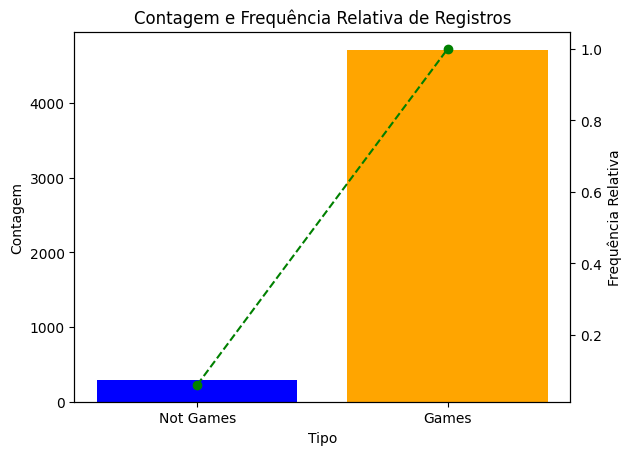

In [ ]:
# Configuração do gráfico de barras
fig, ax1 = plt.subplots()

# Barras de contagem
ax1.bar(['Not Games', 'Games'], [contagem_not_games, 5000 - contagem_not_games], color=['blue', 'orange'])
ax1.set_xlabel('Tipo')
ax1.set_ylabel('Contagem')

# Eixo y secundário para a frequência relativa
ax2 = ax1.twinx()
ax2.plot(['Not Games', 'Games'], [frequencia_relativa, 1], color='green', marker='o', linestyle='--')
ax2.set_ylabel('Frequência Relativa')

plt.title('Contagem e Frequência Relativa de Registros')
plt.show()

# Limpar idade fora do padrão

In [ ]:
def clean_age(age):
    # Remover caracteres não numéricos e converter para inteiro
    if isinstance(age, str):
        return int(''.join(filter(str.isdigit, age)))
    return age

dados_copia['idade'] = dados_copia['idade'].apply(clean_age)

# Criação de nova coluna 'tem_multiplayer'

In [ ]:
# Verificar se 'Multiplayer' ou 'Massively Multiplayer' estão nas tags
dados_copia['tem_multiplayer'] = dados_copia['tags'].apply(lambda x: any(tag in x for tag in ['Multiplayer', 'Massively Multiplayer']) if x is not None else False)


dados_copia

,nome,currentPlayers,peak24h,allTimePeak,tags,analises totais qtd,analises totais positivas,gratuito,idade,generos,categorias,lancamento,tem_multiplayer
0,Counter-Strike 2,1274295,1527573,1818773,"[FPS, Shooter, Multiplayer, Competitive, Actio...",8133285,87,True,0,"[Action, Free to Play]","[Multi-player, Cross-Platform Multiplayer, Ste...","Aug 21, 2012",True
1,Dota 2,697691,716906,1295114,"[Free to Play, MOBA, Multiplayer, Strategy, eS...",2268984,81,True,0,"[Action, Strategy, Free to Play]","[Multi-player, Co-op, Steam Trading Cards, Ste...","Jul 9, 2013",True
2,PUBG: BATTLEGROUNDS,450881,631467,3257248,"[Survival, Shooter, Battle Royale, Multiplayer...",2387631,58,True,0,"[Action, Adventure, Massively Multiplayer, Fre...","[Multi-player, PvP, Online PvP, Stats, Remote ...","Dec 21, 2017",True
3,Apex Legends,245878,357225,624473,"[Free to Play, Battle Royale, Multiplayer, FPS...",841111,77,True,0,"[Action, Adventure, Free to Play]","[Multi-player, PvP, Online PvP, Co-op, Online ...","Nov 4, 2020",True
5,NARAKA: BLADEPOINT,155758,278864,372076,"[Battle Royale, Multiplayer, Martial Arts, PvP...",232270,75,True,0,"[Action, Adventure, Massively Multiplayer]","[Multi-player, PvP, Online PvP, In-App Purchas...","Aug 11, 2021",True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Devil Slayer - Raksasi / 斩妖Raksasi,20,26,1080,"[Difficult, Action Roguelike, Top-Down, Action...",2647,84,False,0,"[Action, Adventure, Indie]","[Single-player, Steam Achievements, Full contr...","Apr 22, 2021",False
4996,DEEEER Simulator: Your Average Everyday Deer Game,20,25,251,"[Exploration, Sandbox, Physics, Funny, Third P...",3307,92,False,0,"[Action, Casual, Indie, Simulation]","[Single-player, Steam Achievements, Partial Co...","Nov 23, 2021",False
4997,Wanba Warriors,20,31,720,"[Fighting, Multiplayer, Funny, Parody , PvP, L...",2195,91,False,0,"[Action, Indie]","[Single-player, Multi-player, PvP, Online PvP,...","Mar 25, 2020",True
4998,Coloring Game,20,31,593,"[Free to Play, Relaxing, Pixel Graphics, Casua...",3855,92,True,0,"[Casual, Free to Play, Indie]","[Single-player, Steam Achievements, Steam Cloud]","Apr 12, 2019",False


# Análise de redundancia nos dados categóricos e exclusão de coluna categorias e tags

In [ ]:
pd.set_option('display.max_colwidth', None)
dados_copia[['categorias','generos','tags']]
pd.reset_option('all')

dados_copia = dados_copia.drop(columns=["categorias","tags"])


dados_copia



C:\Users\sousa\AppData\Local\Temp\ipykernel_16448\3231764292.py:3: FutureWarning: data_manager option is deprecated and will be removed in a future version. Only the BlockManager will be available.
  pd.reset_option('all')
C:\Users\sousa\AppData\Local\Temp\ipykernel_16448\3231764292.py:3: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.reset_option('all')


,nome,currentPlayers,peak24h,allTimePeak,analises totais qtd,analises totais positivas,gratuito,idade,generos,lancamento,tem_multiplayer
0,Counter-Strike 2,1274295,1527573,1818773,8133285,87,True,0,"[Action, Free to Play]","Aug 21, 2012",True
1,Dota 2,697691,716906,1295114,2268984,81,True,0,"[Action, Strategy, Free to Play]","Jul 9, 2013",True
2,PUBG: BATTLEGROUNDS,450881,631467,3257248,2387631,58,True,0,"[Action, Adventure, Massively Multiplayer, Fre...","Dec 21, 2017",True
3,Apex Legends,245878,357225,624473,841111,77,True,0,"[Action, Adventure, Free to Play]","Nov 4, 2020",True
5,NARAKA: BLADEPOINT,155758,278864,372076,232270,75,True,0,"[Action, Adventure, Massively Multiplayer]","Aug 11, 2021",True
...,...,...,...,...,...,...,...,...,...,...,...
4995,Devil Slayer - Raksasi / 斩妖Raksasi,20,26,1080,2647,84,False,0,"[Action, Adventure, Indie]","Apr 22, 2021",False
4996,DEEEER Simulator: Your Average Everyday Deer Game,20,25,251,3307,92,False,0,"[Action, Casual, Indie, Simulation]","Nov 23, 2021",False
4997,Wanba Warriors,20,31,720,2195,91,False,0,"[Action, Indie]","Mar 25, 2020",True
4998,Coloring Game,20,31,593,3855,92,True,0,"[Casual, Free to Play, Indie]","Apr 12, 2019",False


# Calculo do numero de linhas com "generos" nula e exclusão delas

In [ ]:
if dados_copia[dados_copia["generos"].isnull()].shape[0] > 0:
   contagem_cat_gen_null = dados_copia[dados_copia["generos"].isnull()].shape[0]

print(f"contagem_cat_gen_null : {contagem_cat_gen_null }")

dados_copia = dados_copia[dados_copia["generos"].notnull()]

contagem_cat_gen_null : 31


# Calculo do numero de linhas com "analises totais qtd" ou "analises totais positivas" nulo e exclusão delas

In [ ]:
if dados_copia[dados_copia["analises totais qtd"].isnull() | dados_copia["analises totais positivas"].isnull()].shape[0] > 0:
   contagem_analises_null = dados_copia[dados_copia["analises totais qtd"].isnull() | dados_copia["analises totais positivas"].isnull()].shape[0]

print(f"contagem_analises_null : {contagem_analises_null }")

dados_copia = dados_copia[dados_copia["analises totais qtd"].notnull() & dados_copia["analises totais positivas"].notnull()]



contagem_analises_null : 18


# Transformar {Mês dia Ano} em apenas Ano e retirar anos nulos

In [ ]:
def convert_date(date_str):
   for fmt in ("%b %d, %Y", "%b %Y"):
      try:
         return pd.to_datetime(date_str, format=fmt)
      except ValueError:
         continue
   return pd.to_datetime(date_str, errors='coerce')

# Converter a coluna de datas para o tipo datetime
dados_copia['lancamento'] = dados_copia['lancamento'].apply(convert_date)

# Extrair o ano e converter para inteiro
dados_copia['ano_lancamento'] = dados_copia['lancamento'].dt.year

if dados_copia[dados_copia["lancamento"].isnull()].shape[0] > 0:
   contagem_data_null = dados_copia[dados_copia["lancamento"].isnull()].shape[0]

print(f"contagem data nula: {contagem_data_null}")


dados_copia = dados_copia[dados_copia["ano_lancamento"].notnull()]
dados_copia.drop('lancamento', axis=1 ,inplace=True)


contagem data nula: 16


# Visualização dos dados nulos

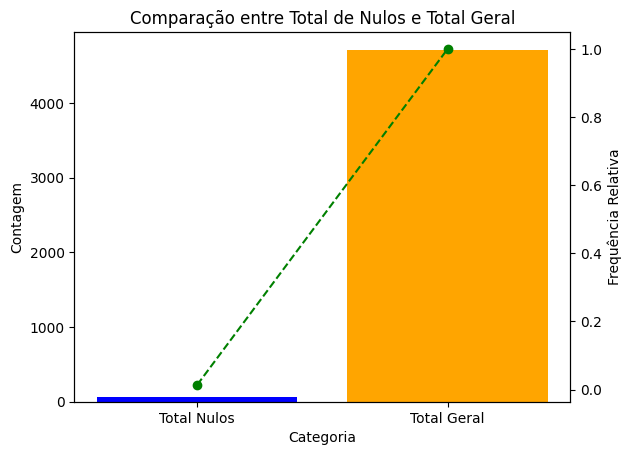

In [ ]:
total_nulos = contagem_analises_null + contagem_cat_gen_null + contagem_data_null

frequencia_relativa_nulos = total_nulos / (5000 - 285)

# Configuração do gráfico de barras
fig, ax1 = plt.subplots()

# Barras de contagem
ax1.bar(['Total Nulos', 'Total Geral'], [total_nulos, (5000 - 285) ], color=['blue', 'orange'])
ax1.set_xlabel('Categoria')
ax1.set_ylabel('Contagem')

# Eixo y secundário para a frequência relativa
ax2 = ax1.twinx()
ax2.plot(['Total Nulos', 'Total Geral'], [frequencia_relativa_nulos, 1], color='green', marker='o', linestyle='--')
ax2.set_ylabel('Frequência Relativa')

plt.title('Comparação entre Total de Nulos e Total Geral')
plt.show()

# Nova coluna com a proporção de jogadores que ainda jogam

In [ ]:
dados_copia['Proporçao_jogadores_restantes'] = dados_copia['peak24h'] / dados_copia['allTimePeak']

dados_copia = dados_copia.drop(columns=['peak24h', 'allTimePeak'])

dados_copia

,nome,currentPlayers,analises totais qtd,analises totais positivas,gratuito,idade,generos,tem_multiplayer,ano_lancamento,Proporçao_jogadores_restantes
0,Counter-Strike 2,1274295,8133285,87,True,0,"[Action, Free to Play]",True,2012.0,0.839892
1,Dota 2,697691,2268984,81,True,0,"[Action, Strategy, Free to Play]",True,2013.0,0.553547
2,PUBG: BATTLEGROUNDS,450881,2387631,58,True,0,"[Action, Adventure, Massively Multiplayer, Fre...",True,2017.0,0.193865
3,Apex Legends,245878,841111,77,True,0,"[Action, Adventure, Free to Play]",True,2020.0,0.572042
5,NARAKA: BLADEPOINT,155758,232270,75,True,0,"[Action, Adventure, Massively Multiplayer]",True,2021.0,0.749481
...,...,...,...,...,...,...,...,...,...,...
4995,Devil Slayer - Raksasi / 斩妖Raksasi,20,2647,84,False,0,"[Action, Adventure, Indie]",False,2021.0,0.024074
4996,DEEEER Simulator: Your Average Everyday Deer Game,20,3307,92,False,0,"[Action, Casual, Indie, Simulation]",False,2021.0,0.099602
4997,Wanba Warriors,20,2195,91,False,0,"[Action, Indie]",True,2020.0,0.043056
4998,Coloring Game,20,3855,92,True,0,"[Casual, Free to Play, Indie]",False,2019.0,0.052277


# Nova coluna numero de análises positivas

In [ ]:
dados_copia['numero_de_analises_positivas'] = dados_copia['analises totais qtd'] * (dados_copia['analises totais positivas']/100)

dados_copia = dados_copia.drop(columns=['analises totais positivas','analises totais qtd'])
dados_copia

,nome,currentPlayers,gratuito,idade,generos,tem_multiplayer,ano_lancamento,Proporçao_jogadores_restantes,numero_de_analises_positivas
0,Counter-Strike 2,1274295,True,0,"[Action, Free to Play]",True,2012.0,0.839892,7075957.95
1,Dota 2,697691,True,0,"[Action, Strategy, Free to Play]",True,2013.0,0.553547,1837877.04
2,PUBG: BATTLEGROUNDS,450881,True,0,"[Action, Adventure, Massively Multiplayer, Fre...",True,2017.0,0.193865,1384825.98
3,Apex Legends,245878,True,0,"[Action, Adventure, Free to Play]",True,2020.0,0.572042,647655.47
5,NARAKA: BLADEPOINT,155758,True,0,"[Action, Adventure, Massively Multiplayer]",True,2021.0,0.749481,174202.5
...,...,...,...,...,...,...,...,...,...
4995,Devil Slayer - Raksasi / 斩妖Raksasi,20,False,0,"[Action, Adventure, Indie]",False,2021.0,0.024074,2223.48
4996,DEEEER Simulator: Your Average Everyday Deer Game,20,False,0,"[Action, Casual, Indie, Simulation]",False,2021.0,0.099602,3042.44
4997,Wanba Warriors,20,False,0,"[Action, Indie]",True,2020.0,0.043056,1997.45
4998,Coloring Game,20,True,0,"[Casual, Free to Play, Indie]",False,2019.0,0.052277,3546.6


# Normalização das análises positivas considerando o numero atual de jogadores

In [ ]:
dados_copia['numero_de_analises_positivas'] = dados_copia['numero_de_analises_positivas'] / dados_copia['currentPlayers']

dados_copia

,nome,currentPlayers,gratuito,idade,generos,tem_multiplayer,ano_lancamento,Proporçao_jogadores_restantes,numero_de_analises_positivas
0,Counter-Strike 2,1274295,True,0,"[Action, Free to Play]",True,2012.0,0.839892,5.552841
1,Dota 2,697691,True,0,"[Action, Strategy, Free to Play]",True,2013.0,0.553547,2.634228
2,PUBG: BATTLEGROUNDS,450881,True,0,"[Action, Adventure, Massively Multiplayer, Fre...",True,2017.0,0.193865,3.071378
3,Apex Legends,245878,True,0,"[Action, Adventure, Free to Play]",True,2020.0,0.572042,2.634052
5,NARAKA: BLADEPOINT,155758,True,0,"[Action, Adventure, Massively Multiplayer]",True,2021.0,0.749481,1.118418
...,...,...,...,...,...,...,...,...,...
4995,Devil Slayer - Raksasi / 斩妖Raksasi,20,False,0,"[Action, Adventure, Indie]",False,2021.0,0.024074,111.174
4996,DEEEER Simulator: Your Average Everyday Deer Game,20,False,0,"[Action, Casual, Indie, Simulation]",False,2021.0,0.099602,152.122
4997,Wanba Warriors,20,False,0,"[Action, Indie]",True,2020.0,0.043056,99.8725
4998,Coloring Game,20,True,0,"[Casual, Free to Play, Indie]",False,2019.0,0.052277,177.33


# Descrição dos dados numéricos básicos

In [ ]:

print(dados_copia.info())

print(dados_copia.describe())

print(dados_copia.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 4650 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   nome                           4650 non-null   object 
 1   currentPlayers                 4650 non-null   int64  
 2   gratuito                       4650 non-null   object 
 3   idade                          4650 non-null   int64  
 4   generos                        4650 non-null   object 
 5   tem_multiplayer                4650 non-null   bool   
 6   ano_lancamento                 4650 non-null   float64
 7   Proporçao_jogadores_restantes  4650 non-null   float64
 8   numero_de_analises_positivas   4650 non-null   object 
dtypes: bool(1), float64(2), int64(2), object(4)
memory usage: 331.5+ KB
None
       currentPlayers        idade  ano_lancamento  \
count    4.650000e+03  4650.000000     4650.000000   
mean     1.801619e+03     1.760860     2019.290108   

# Normalização dos dados numéricos usando Max-Min

In [ ]:
# Selecionando as colunas numéricas para normalização
numeric_columns = [ 'currentPlayers' ,'numero_de_analises_positivas','Proporçao_jogadores_restantes','ano_lancamento','idade','tem_multiplayer']

# Aplicando Min-Max Scaling
scaler = MinMaxScaler()
dados_copia[numeric_columns] = scaler.fit_transform(dados_copia[numeric_columns])

dados_copia

,nome,currentPlayers,gratuito,idade,generos,tem_multiplayer,ano_lancamento,Proporçao_jogadores_restantes,numero_de_analises_positivas
0,Counter-Strike 2,1.000000,True,0.0,"[Action, Free to Play]",1.0,0.555556,0.839881,0.003241
1,Dota 2,0.547504,True,0.0,"[Action, Strategy, Free to Play]",1.0,0.592593,0.553516,0.001535
2,PUBG: BATTLEGROUNDS,0.353818,True,0.0,"[Action, Adventure, Massively Multiplayer, Fre...",1.0,0.740741,0.193811,0.001790
3,Apex Legends,0.192940,True,0.0,"[Action, Adventure, Free to Play]",1.0,0.851852,0.572013,0.001534
5,NARAKA: BLADEPOINT,0.122217,True,0.0,"[Action, Adventure, Massively Multiplayer]",1.0,0.888889,0.749464,0.000648
...,...,...,...,...,...,...,...,...,...
4995,Devil Slayer - Raksasi / 斩妖Raksasi,0.000000,False,0.0,"[Action, Adventure, Indie]",0.0,0.888889,0.024008,0.064998
4996,DEEEER Simulator: Your Average Everyday Deer Game,0.000000,False,0.0,"[Action, Casual, Indie, Simulation]",0.0,0.888889,0.099541,0.088940
4997,Wanba Warriors,0.000000,False,0.0,"[Action, Indie]",1.0,0.851852,0.042991,0.058390
4998,Coloring Game,0.000000,True,0.0,"[Casual, Free to Play, Indie]",0.0,0.814815,0.052213,0.103680


# Transformar coluna "gratuito" e "tem_multiplayer" em 0 ou 1

In [ ]:
# Transformar a coluna gratuito em 0 ou 1
dados_copia['gratuito'] = dados_copia['gratuito'].astype(int)
dados_copia['tem_multiplayer'] = dados_copia['tem_multiplayer'].astype(int)

dados_copia

,nome,currentPlayers,gratuito,idade,generos,tem_multiplayer,ano_lancamento,Proporçao_jogadores_restantes,numero_de_analises_positivas
0,Counter-Strike 2,1.000000,1,0.0,"[Action, Free to Play]",1,0.555556,0.839881,0.003241
1,Dota 2,0.547504,1,0.0,"[Action, Strategy, Free to Play]",1,0.592593,0.553516,0.001535
2,PUBG: BATTLEGROUNDS,0.353818,1,0.0,"[Action, Adventure, Massively Multiplayer, Fre...",1,0.740741,0.193811,0.001790
3,Apex Legends,0.192940,1,0.0,"[Action, Adventure, Free to Play]",1,0.851852,0.572013,0.001534
5,NARAKA: BLADEPOINT,0.122217,1,0.0,"[Action, Adventure, Massively Multiplayer]",1,0.888889,0.749464,0.000648
...,...,...,...,...,...,...,...,...,...
4995,Devil Slayer - Raksasi / 斩妖Raksasi,0.000000,0,0.0,"[Action, Adventure, Indie]",0,0.888889,0.024008,0.064998
4996,DEEEER Simulator: Your Average Everyday Deer Game,0.000000,0,0.0,"[Action, Casual, Indie, Simulation]",0,0.888889,0.099541,0.088940
4997,Wanba Warriors,0.000000,0,0.0,"[Action, Indie]",1,0.851852,0.042991,0.058390
4998,Coloring Game,0.000000,1,0.0,"[Casual, Free to Play, Indie]",0,0.814815,0.052213,0.103680


# Separação dos dados em numéricos

In [ ]:
dados_numericos = dados_copia.drop(columns=['nome','generos'])

print(dados_numericos)

      currentPlayers  gratuito  idade  tem_multiplayer  ano_lancamento  \
0           1.000000         1    0.0                1        0.555556   
1           0.547504         1    0.0                1        0.592593   
2           0.353818         1    0.0                1        0.740741   
3           0.192940         1    0.0                1        0.851852   
5           0.122217         1    0.0                1        0.888889   
...              ...       ...    ...              ...             ...   
4995        0.000000         0    0.0                0        0.888889   
4996        0.000000         0    0.0                0        0.888889   
4997        0.000000         0    0.0                1        0.851852   
4998        0.000000         1    0.0                0        0.814815   
4999        0.000000         0    0.0                1        0.814815   

      Proporçao_jogadores_restantes  numero_de_analises_positivas  
0                          0.839881        

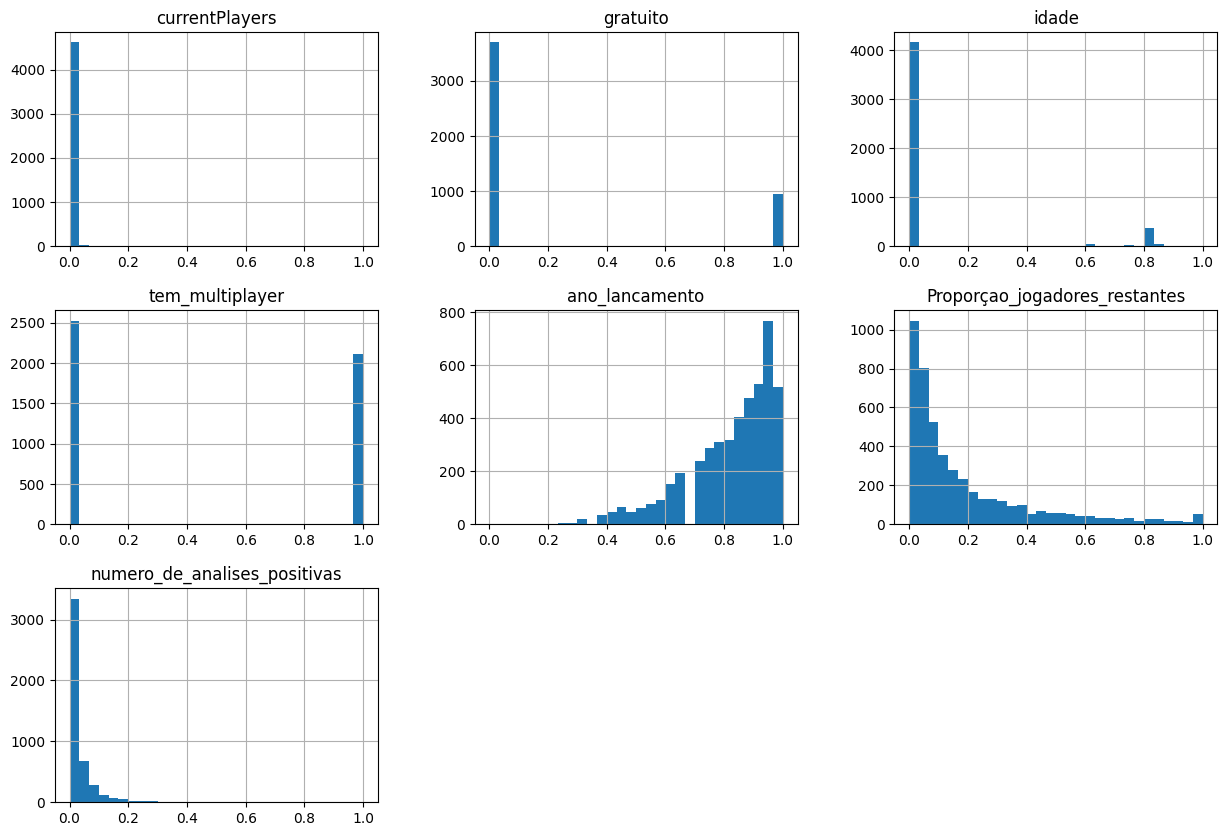

In [ ]:
dados_numericos.hist(bins=30, figsize=(15, 10))
plt.show()

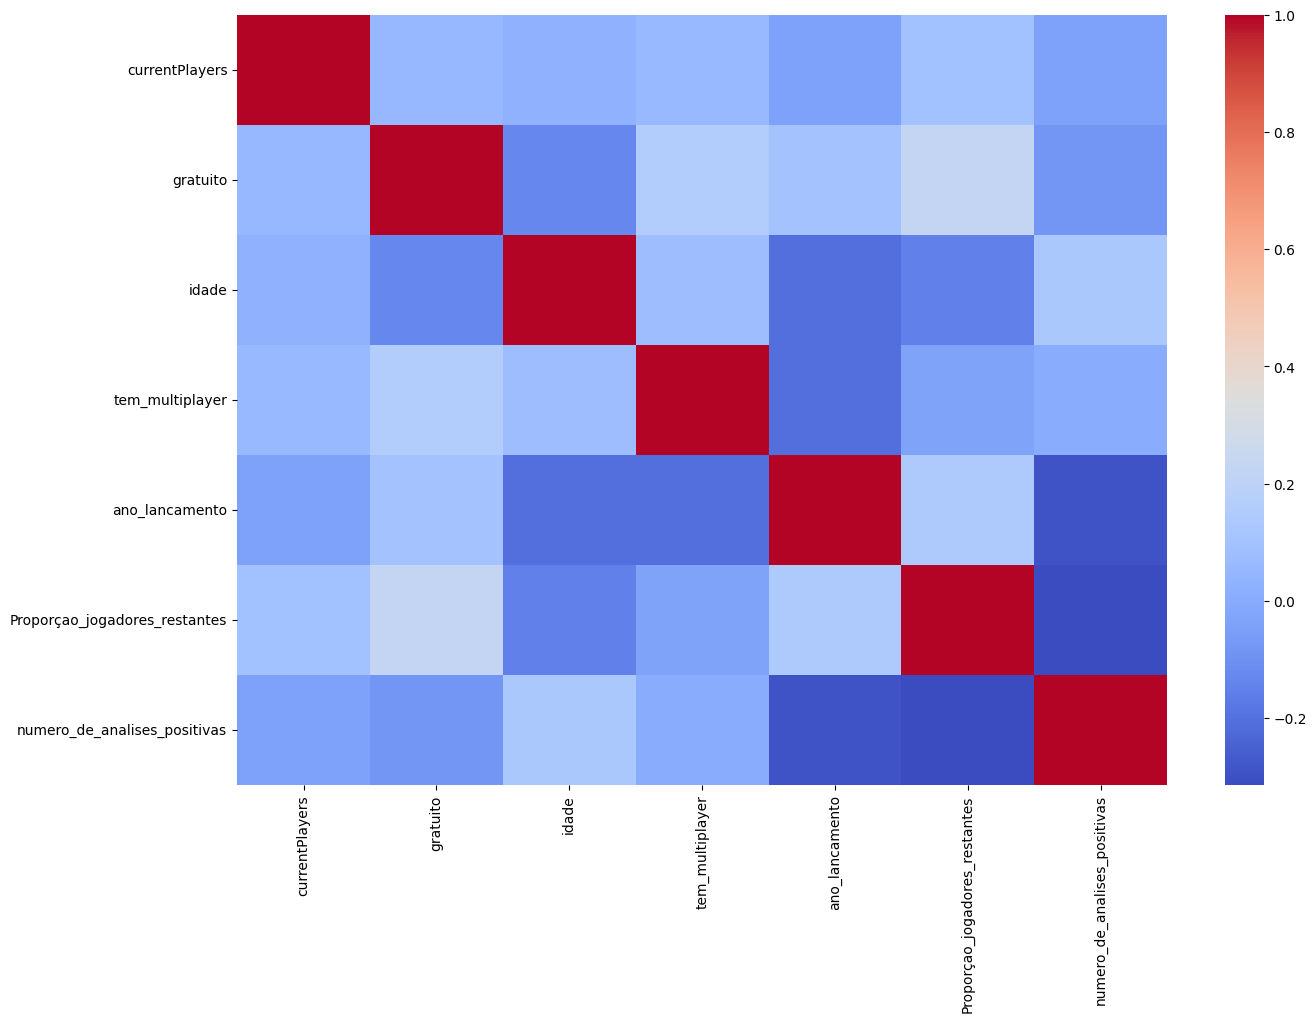

In [ ]:
# Calcula a matriz de correlação entre as colunas numéricas do DataFrame dados_numericos
correlation_matrix = dados_numericos.corr()

plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=False, fmt=".2f", cmap='coolwarm')
plt.show()

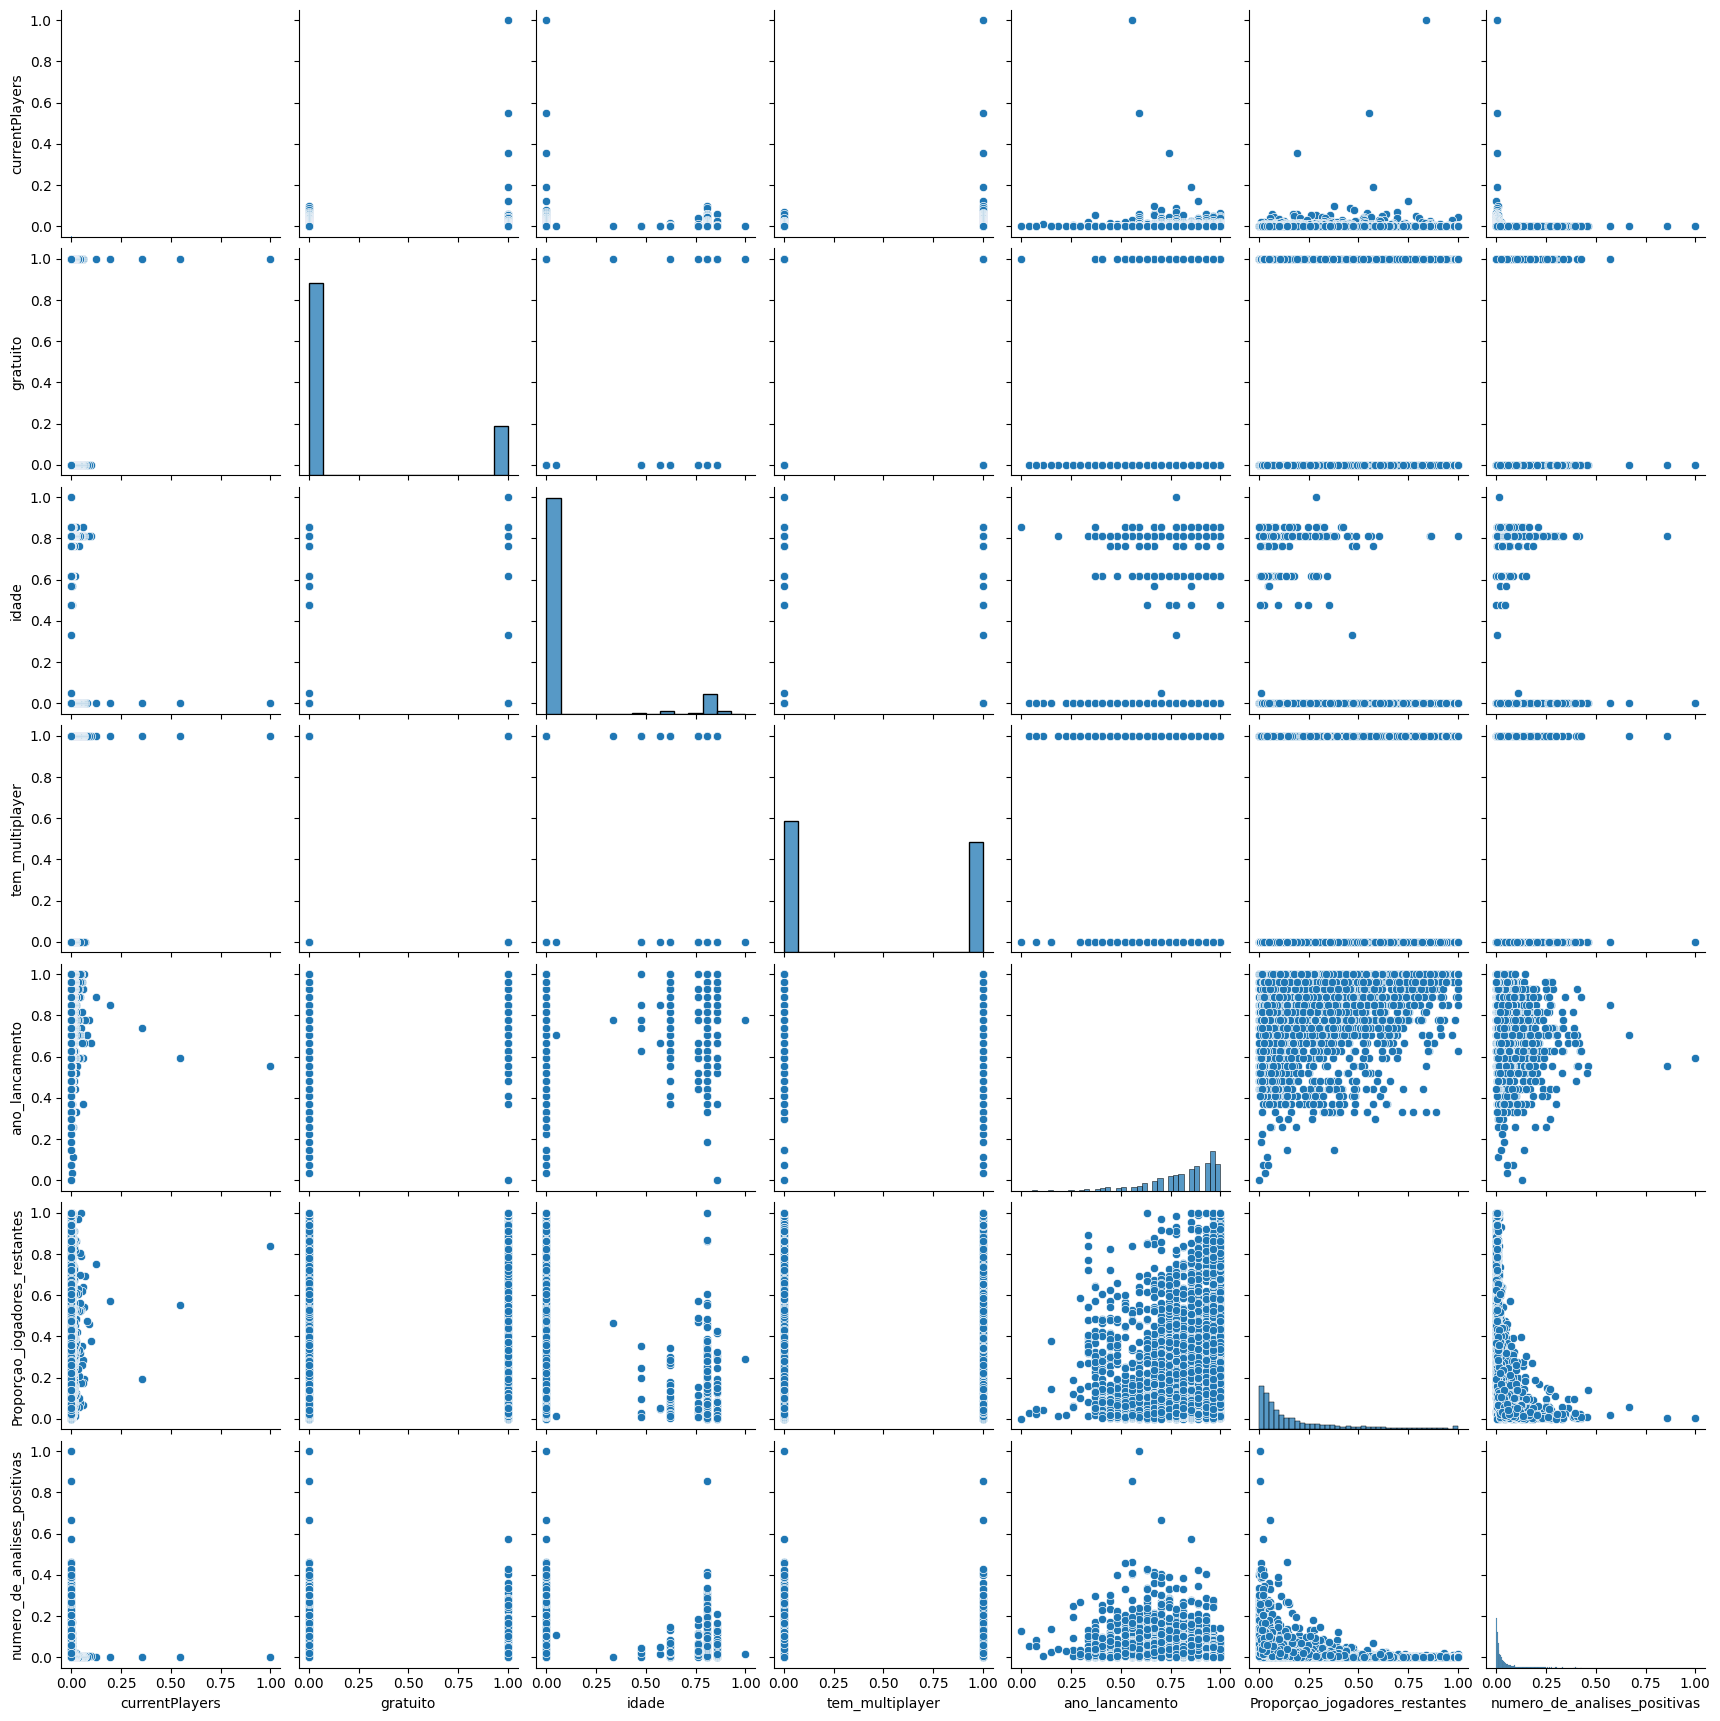

In [ ]:
sns.pairplot(dados_numericos)
plt.show()

# Plotagem do dendograma hierárquico

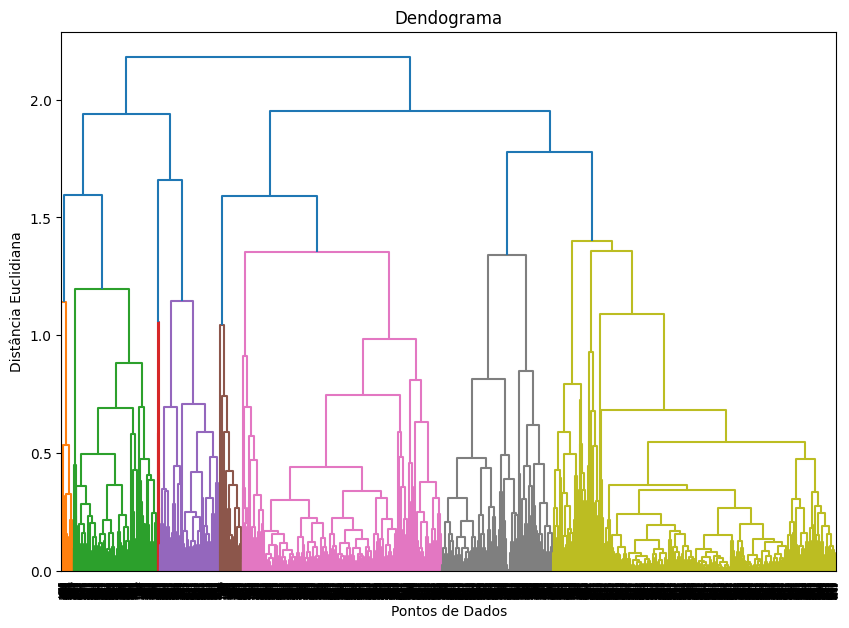

In [ ]:
# Clusterização hierárquica com ligação completa
linked = sch.linkage(dados_numericos, method='complete')

# Plot do dendograma
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(linked)
plt.title('Dendograma')
plt.xlabel('Pontos de Dados')
plt.ylabel('Distância Euclidiana')
plt.show()

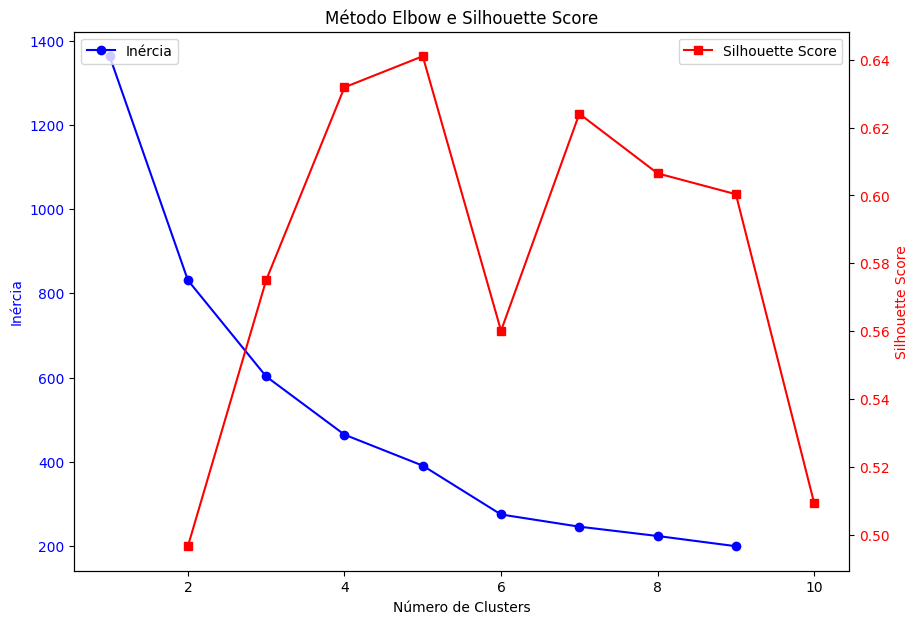

In [ ]:
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []

for i in range(2, 11):  # Silhouette score não pode ser calculado para k=1
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(dados_numericos)

    # Inércia
    inertia.append(kmeans.inertia_)

    # Calcular o silhouette score
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(dados_numericos, labels)
    silhouette_scores.append(silhouette_avg)

# Plot do gráfico de Elbow com Silhouette Score
fig, ax1 = plt.subplots(figsize=(10, 7))

# Gráfico da inércia
ax1.plot(range(1, 11), inertia + [None], marker='o', color='b', label='Inércia')
ax1.set_xlabel('Número de Clusters')
ax1.set_ylabel('Inércia', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Criar um segundo eixo y para o silhouette score
ax2 = ax1.twinx()
ax2.plot(range(2, 11), silhouette_scores, marker='s', color='r', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Adicionar título e legendas
plt.title('Método Elbow e Silhouette Score')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()

In [ ]:
n_clusters = 5

# Aplicar K-Means
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(dados_numericos)

# Adicionar os clusters ao dataframe original
dados_copia['Cluster'] = clusters



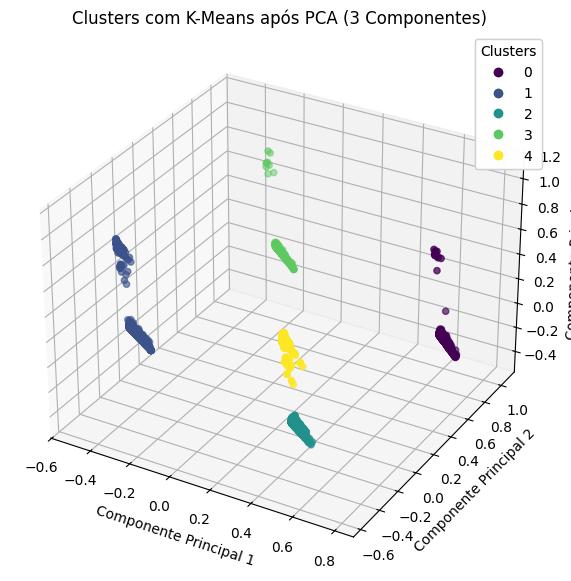

In [ ]:
# Aplicar PCA para reduzir para 3 componentes
pca = PCA(n_components=3)
df_pca_3d = pca.fit_transform(dados_numericos)

# Visualização dos clusters em 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df_pca_3d[:, 0], df_pca_3d[:, 1], df_pca_3d[:, 2], c=clusters, cmap='viridis')
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_zlabel('Componente Principal 3')
ax.set_title('Clusters com K-Means após PCA (3 Componentes)')
plt.show()



# Análise dos Clusteres

In [ ]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

# Descrever as estatísticas para cada cluster
cluster_stats = dados_copia.groupby('Cluster').describe()

print(cluster_stats)

pd.reset_option('all')



        currentPlayers                                                                  gratuito                                      idade                                                                      tem_multiplayer                                    ano_lancamento                                                                  Proporçao_jogadores_restantes                                                                  numero_de_analises_positivas                                                                      
                 count      mean       std  min       25%       50%       75%       max    count mean  std  min  25%  50%  75%  max   count      mean       std      min       25%       50%       75%       max           count mean  std  min  25%  50%  75%  max          count      mean       std       min       25%       50%       75%  max                         count      mean       std       min       25%       50%       75%  max                        count   

C:\Users\sousa\AppData\Local\Temp\ipykernel_16448\3879056320.py:10: FutureWarning: data_manager option is deprecated and will be removed in a future version. Only the BlockManager will be available.
  pd.reset_option('all')
C:\Users\sousa\AppData\Local\Temp\ipykernel_16448\3879056320.py:10: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.reset_option('all')


In [ ]:
# Supondo que 'dados_copia' seja o seu dataframe
# Explodir a coluna 'generos' para que cada gênero tenha sua própria linha
dados_explodidos = dados_copia.explode('generos')

# Contar a frequência de cada gênero dentro de cada cluster
generos_por_cluster = dados_explodidos.groupby('Cluster')['generos'].value_counts().unstack(fill_value=0)

# Exibir a contagem
print(generos_por_cluster)

generos  Action  Adventure  Animation & Modeling  Audio Production  Casual  \
Cluster                                                                      
0           296        180                     1                 0     179   
1           729        899                    33                14     484   
2           636        358                     3                 2     217   
3            84        121                    15                 3     186   
4           226         92                     0                 0       2   

generos  Design & Illustration  Early Access  Education  Free to Play  \
Cluster                                                                 
0                            0            48          0           505   
1                           41           258         15             1   
2                            5           146          2             5   
3                           10            44          2           265   
4              

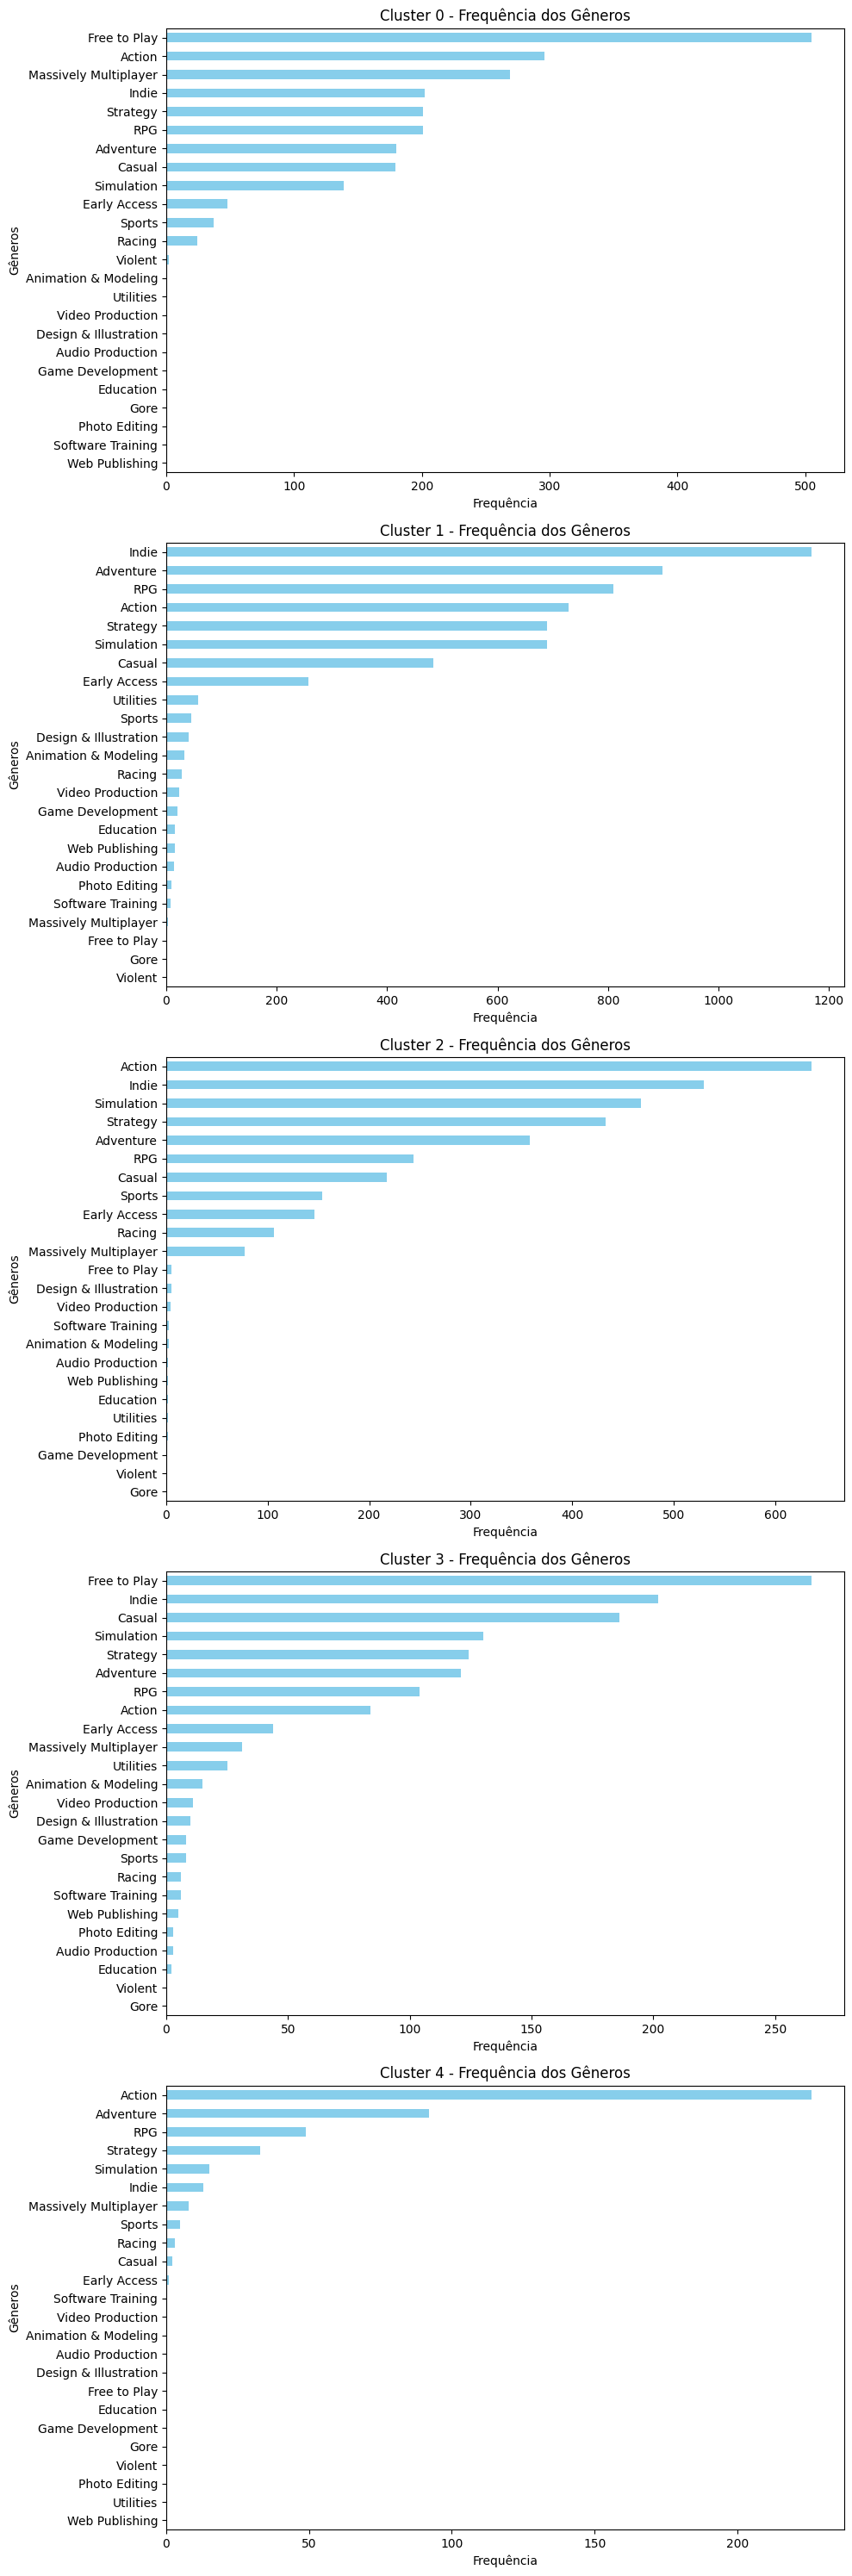

In [ ]:
# Criar uma visualização para cada cluster
clusters = generos_por_cluster.index

fig, axes = plt.subplots(nrows=len(clusters), ncols=1, figsize=(10, 6*len(clusters)))

for idx, cluster in enumerate(clusters):
    generos_por_cluster.loc[cluster].sort_values().plot(kind='barh', ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Cluster {cluster} - Frequência dos Gêneros')
    axes[idx].set_xlabel('Frequência')
    axes[idx].set_ylabel('Gêneros')

plt.tight_layout()
plt.show()


In [ ]:
dados_copia[dados_copia['Cluster'] == 0]

,nome,currentPlayers,gratuito,idade,generos,tem_multiplayer,ano_lancamento,Proporçao_jogadores_restantes,numero_de_analises_positivas,Cluster
0,Counter-Strike 2,1.000000e+00,1,0.0,"[Action, Free to Play]",1,0.555556,0.839881,0.003241,0
1,Dota 2,5.475043e-01,1,0.0,"[Action, Strategy, Free to Play]",1,0.592593,0.553516,0.001535,0
2,PUBG: BATTLEGROUNDS,3.538177e-01,1,0.0,"[Action, Adventure, Massively Multiplayer, Fre...",1,0.740741,0.193811,0.001790,0
3,Apex Legends,1.929395e-01,1,0.0,"[Action, Adventure, Free to Play]",1,0.851852,0.572013,0.001534,0
5,NARAKA: BLADEPOINT,1.222169e-01,1,0.0,"[Action, Adventure, Massively Multiplayer]",1,0.888889,0.749464,0.000648,0
...,...,...,...,...,...,...,...,...,...,...
4943,Luckcatchers2,7.847600e-07,1,0.0,"[Indie, Massively Multiplayer, Strategy]",1,1.000000,0.473649,0.001879,0
4961,WWII Online,0.000000e+00,1,0.0,"[Action, Casual, Indie, Massively Multiplayer,...",1,0.962963,0.047971,0.051923,0
4971,The Lab,0.000000e+00,1,0.0,[Free to Play],1,0.703704,0.032297,0.167436,0
4982,Stormbound,0.000000e+00,1,0.0,"[Free to Play, Indie, Strategy]",1,0.777778,0.105600,0.022853,0
